# How AI Learns from Data
**ME 493B · Session 4 · April 9, 2026**

Every AI model — from linear regression to GPT — learns the same way:
1. Make a prediction
2. Measure the error (loss)
3. Adjust parameters to reduce error

Today we'll build this loop from scratch using a dataset you can reason about physically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Style for dark slides / projector readability
plt.style.use('dark_background')
plt.rcParams.update({'font.size': 13, 'figure.figsize': (10, 5)})

## 1. The Data: Auto MPG

398 cars from the 1970s–80s. We want to predict fuel efficiency (MPG) from physical properties.

**Engineering intuition**: A heavier car should get worse mileage. Let's see if the data agrees.

In [2]:
# Load the Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url).dropna()

print(f"{len(df)} cars loaded")
df[['mpg','weight','horsepower','cylinders','acceleration']].describe().round(1)

392 cars loaded


,mpg,weight,horsepower,cylinders,acceleration
count,392.0,392.0,392.0,392.0,392.0
mean,23.4,2977.6,104.5,5.5,15.5
std,7.8,849.4,38.5,1.7,2.8
min,9.0,1613.0,46.0,3.0,8.0
25%,17.0,2225.2,75.0,4.0,13.8
50%,22.8,2803.5,93.5,4.0,15.5
75%,29.0,3614.8,126.0,8.0,17.0
max,46.6,5140.0,230.0,8.0,24.8


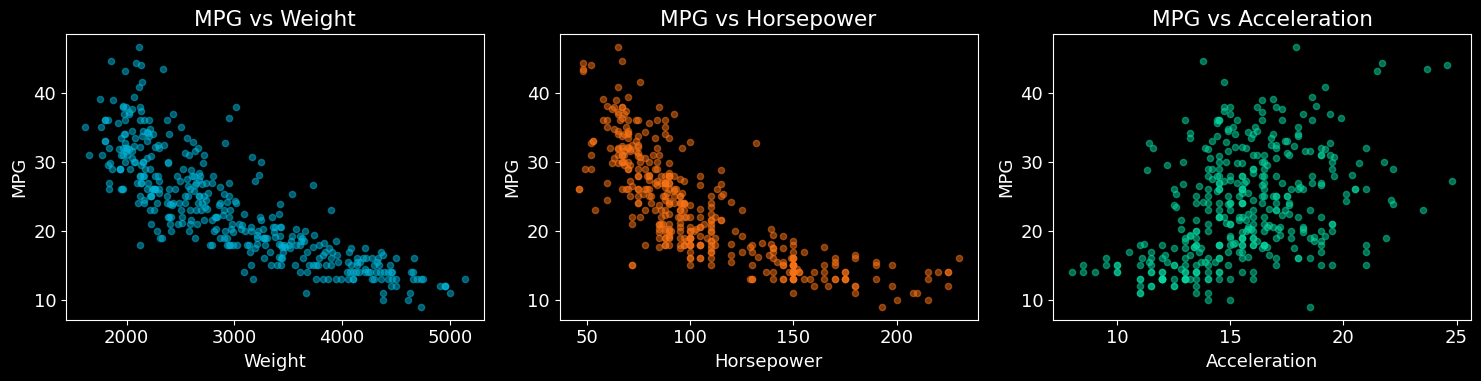


Which feature has the clearest relationship with MPG?


In [3]:
# Let's look at the relationship
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, color in zip(axes, ['weight', 'horsepower', 'acceleration'], 
                            ['#00B4D8', '#F97316', '#06D6A0']):
    ax.scatter(df[feat], df['mpg'], alpha=0.5, s=20, color=color)
    ax.set_xlabel(feat.title())
    ax.set_ylabel('MPG')
    ax.set_title(f'MPG vs {feat.title()}')

plt.tight_layout()
plt.show()
print("\nWhich feature has the clearest relationship with MPG?")

## 2. What Is a Model?

A **model** is just a function with adjustable parameters.

Simplest possible model: a straight line.

$$\hat{y} = w \cdot x + b$$

- $w$ (weight/slope): how much MPG changes per pound
- $b$ (bias/intercept): MPG when weight = 0 (extrapolation)
- $\hat{y}$: our **prediction**

Let's start by guessing parameters — be an engineer, use your intuition.

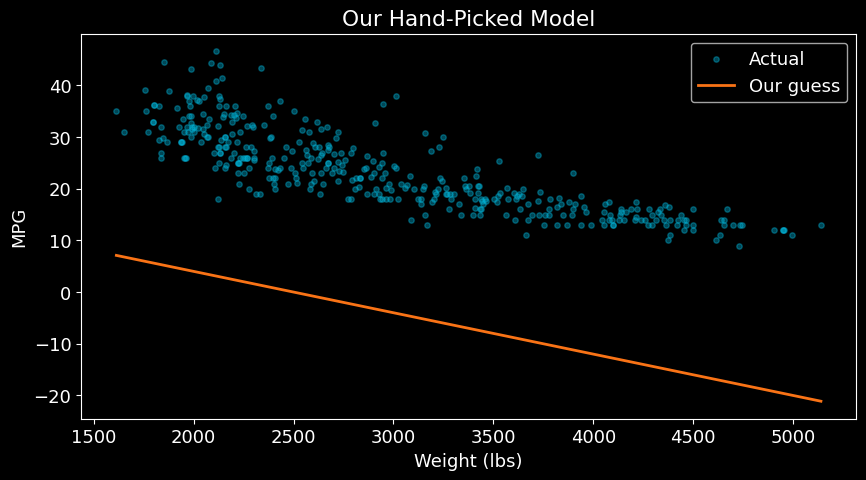

Parameters: w=-0.008, b=20.0
Prediction for a 3000 lb car: -4.0 MPG


In [4]:
# Extract our feature and target
x = df['weight'].values
y = df['mpg'].values

# YOUR GUESS: what slope and intercept make sense?
# Heavier car → worse MPG, so slope should be negative
# A 3000 lb car gets ~20 mpg, so intercept should be ~45-50
w_guess = -0.008   # Try changing this!
b_guess = 20.0     # Try changing this!

y_pred = w_guess * x + b_guess

plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.4, s=15, color='#00B4D8', label='Actual')
plt.plot(sorted(x), w_guess * np.sort(x) + b_guess, color='#F97316', linewidth=2, label='Our guess')
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.title('Our Hand-Picked Model')
plt.legend()
plt.show()

print(f"Parameters: w={w_guess}, b={b_guess}")
print(f"Prediction for a 3000 lb car: {w_guess * 3000 + b_guess:.1f} MPG")

## 3. What Is a Loss Function?

How do we know if our guess is **good**? We need a single number that says "how wrong are we?"

**Mean Squared Error (MSE)**:
$$L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

- Each error is squared (so big mistakes count way more than small ones)
- Averaged over all data points
- Lower = better. Zero = perfect (but suspicious!)

Our guess loss (MSE): 762.23


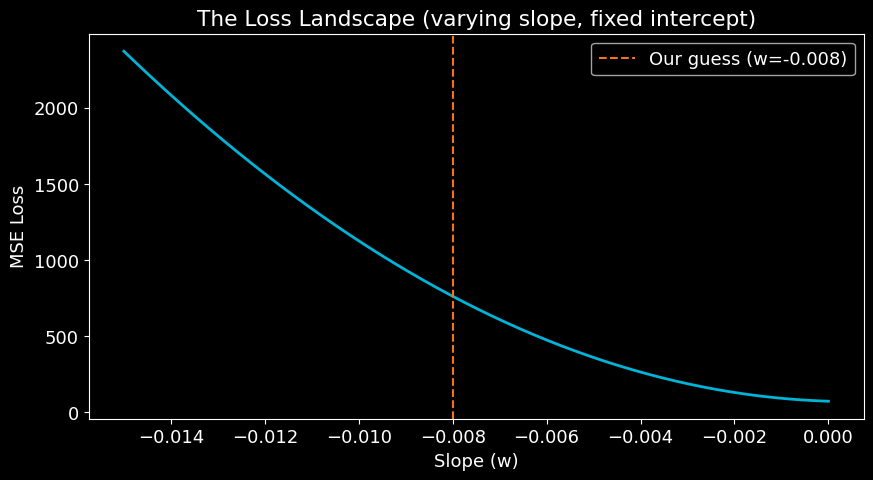

Best slope in this range: 0.00000 → MSE: 72.64


In [5]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# How good is our guess?
our_loss = mse(y, w_guess * x + b_guess)
print(f"Our guess loss (MSE): {our_loss:.2f}")

# Let's see what different slopes look like
slopes = np.linspace(-0.015, 0.0, 200)
losses = [mse(y, s * x + b_guess) for s in slopes]

plt.figure(figsize=(10, 5))
plt.plot(slopes, losses, color='#00B4D8', linewidth=2)
plt.axvline(w_guess, color='#F97316', linestyle='--', label=f'Our guess (w={w_guess})')
plt.xlabel('Slope (w)')
plt.ylabel('MSE Loss')
plt.title('The Loss Landscape (varying slope, fixed intercept)')
plt.legend()
plt.show()

best_slope = slopes[np.argmin(losses)]
print(f"Best slope in this range: {best_slope:.5f} → MSE: {min(losses):.2f}")

### The Loss Landscape in 2D

With two parameters (w and b), the loss function is a **surface** — a bowl shape.
Training = rolling a ball downhill to find the bottom.

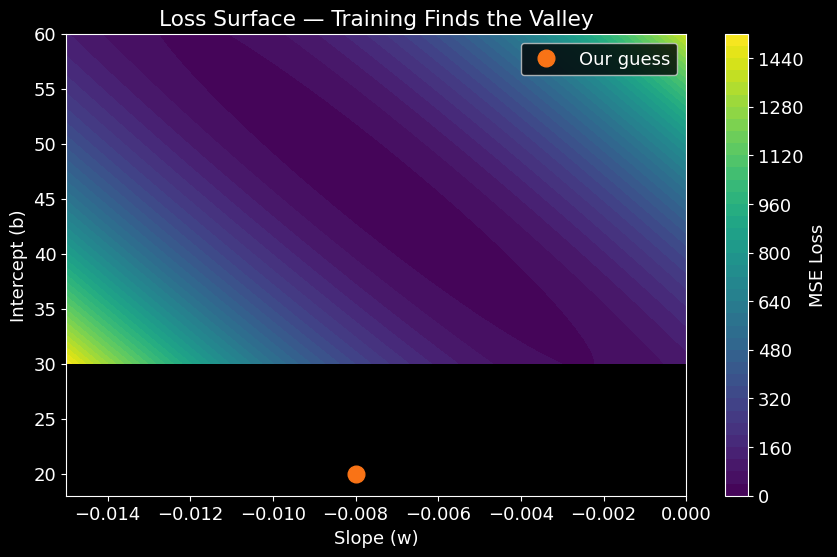

In [6]:
# Visualize the full loss surface
w_range = np.linspace(-0.015, 0.0, 80)
b_range = np.linspace(30, 60, 80)
W, B = np.meshgrid(w_range, b_range)
L = np.array([[mse(y, w * x + b) for w in w_range] for b in b_range])

fig, ax = plt.subplots(figsize=(10, 6))
cp = ax.contourf(W, B, L, levels=40, cmap='viridis')
plt.colorbar(cp, label='MSE Loss')
ax.plot(w_guess, b_guess, 'o', color='#F97316', markersize=12, label='Our guess')
ax.set_xlabel('Slope (w)')
ax.set_ylabel('Intercept (b)')
ax.set_title('Loss Surface — Training Finds the Valley')
ax.legend()
plt.show()

## 4. What Is Training? (Gradient Descent)

Instead of trying every combination, we use **calculus** to find the downhill direction:

1. Compute the gradient (which direction is steepest downhill?)
2. Take a small step in that direction
3. Repeat

$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}$$

The learning rate $\alpha$ controls step size. Too big = overshoot. Too small = slow.

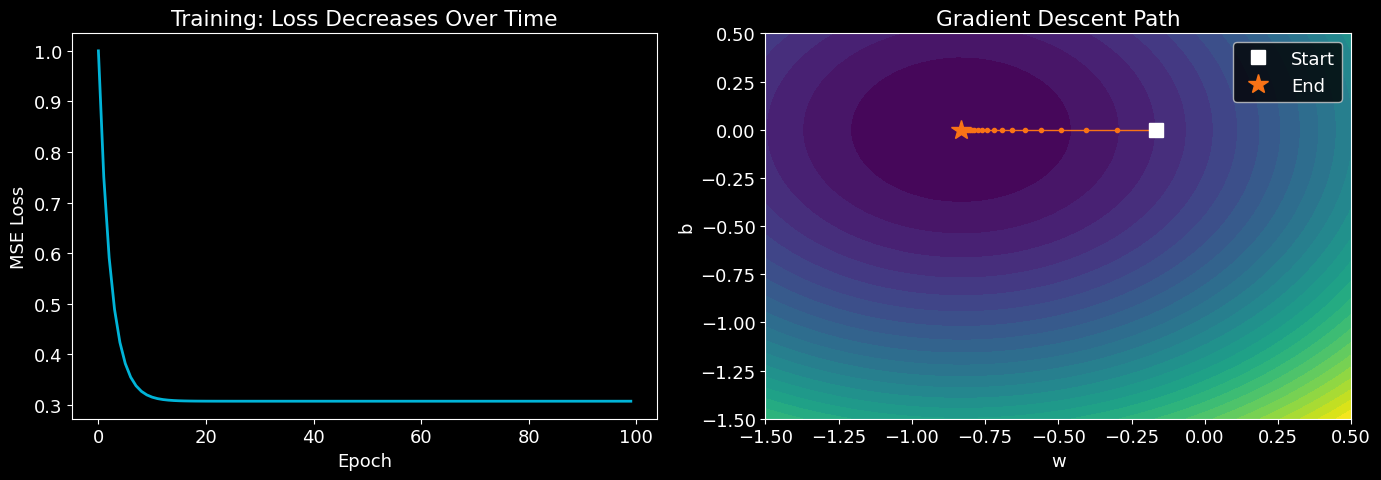

Learned: MPG = -0.00765 × weight + 46.2
Final MSE (original scale): 18.68


In [7]:
# Normalize features for stable training
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()
x_norm = (x - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Gradient descent from scratch
w = 0.0  # start at zero
b = 0.0
lr = 0.1  # learning rate
N = len(x_norm)
history = []

for epoch in range(100):
    # Forward pass: make predictions
    y_hat = w * x_norm + b
    
    # Compute loss
    loss = np.mean((y_norm - y_hat) ** 2)
    
    # Compute gradients (partial derivatives)
    dw = -2 / N * np.sum(x_norm * (y_norm - y_hat))
    db = -2 / N * np.sum(y_norm - y_hat)
    
    # Update parameters
    w -= lr * dw
    b -= lr * db
    
    history.append({'epoch': epoch, 'loss': loss, 'w': w, 'b': b})

hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss over time
axes[0].plot(hist['epoch'], hist['loss'], color='#00B4D8', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training: Loss Decreases Over Time')

# Parameter trajectory on loss surface
axes[1].contourf(np.linspace(-1.5, 0.5, 50), np.linspace(-1.5, 0.5, 50),
                 [[np.mean((y_norm - ww * x_norm - bb)**2) for ww in np.linspace(-1.5, 0.5, 50)] 
                  for bb in np.linspace(-1.5, 0.5, 50)],
                 levels=30, cmap='viridis')
axes[1].plot(hist['w'], hist['b'], 'o-', color='#F97316', markersize=3, linewidth=1)
axes[1].plot(hist['w'].iloc[0], hist['b'].iloc[0], 's', color='white', markersize=10, label='Start')
axes[1].plot(hist['w'].iloc[-1], hist['b'].iloc[-1], '*', color='#F97316', markersize=15, label='End')
axes[1].set_xlabel('w'); axes[1].set_ylabel('b')
axes[1].set_title('Gradient Descent Path')
axes[1].legend()

plt.tight_layout()
plt.show()

# Convert back to original scale
w_final = w * y_std / x_std
b_final = y_mean - w_final * x_mean + b * y_std
print(f"Learned: MPG = {w_final:.5f} × weight + {b_final:.1f}")
print(f"Final MSE (original scale): {mse(y, w_final * x + b_final):.2f}")

### 🔧 Try This: Learning Rate

Go back and change `lr` to:
- `0.01` (too slow — does it converge in 100 epochs?)
- `1.0` (too fast — what happens?)
- `0.5` (just right?)

## 5. Overfitting: Memorizing Noise vs. Learning Signal

A more complex model can fit the training data perfectly. But that doesn't mean it **understands** the data.

We'll fit polynomials of increasing degree and see what happens.

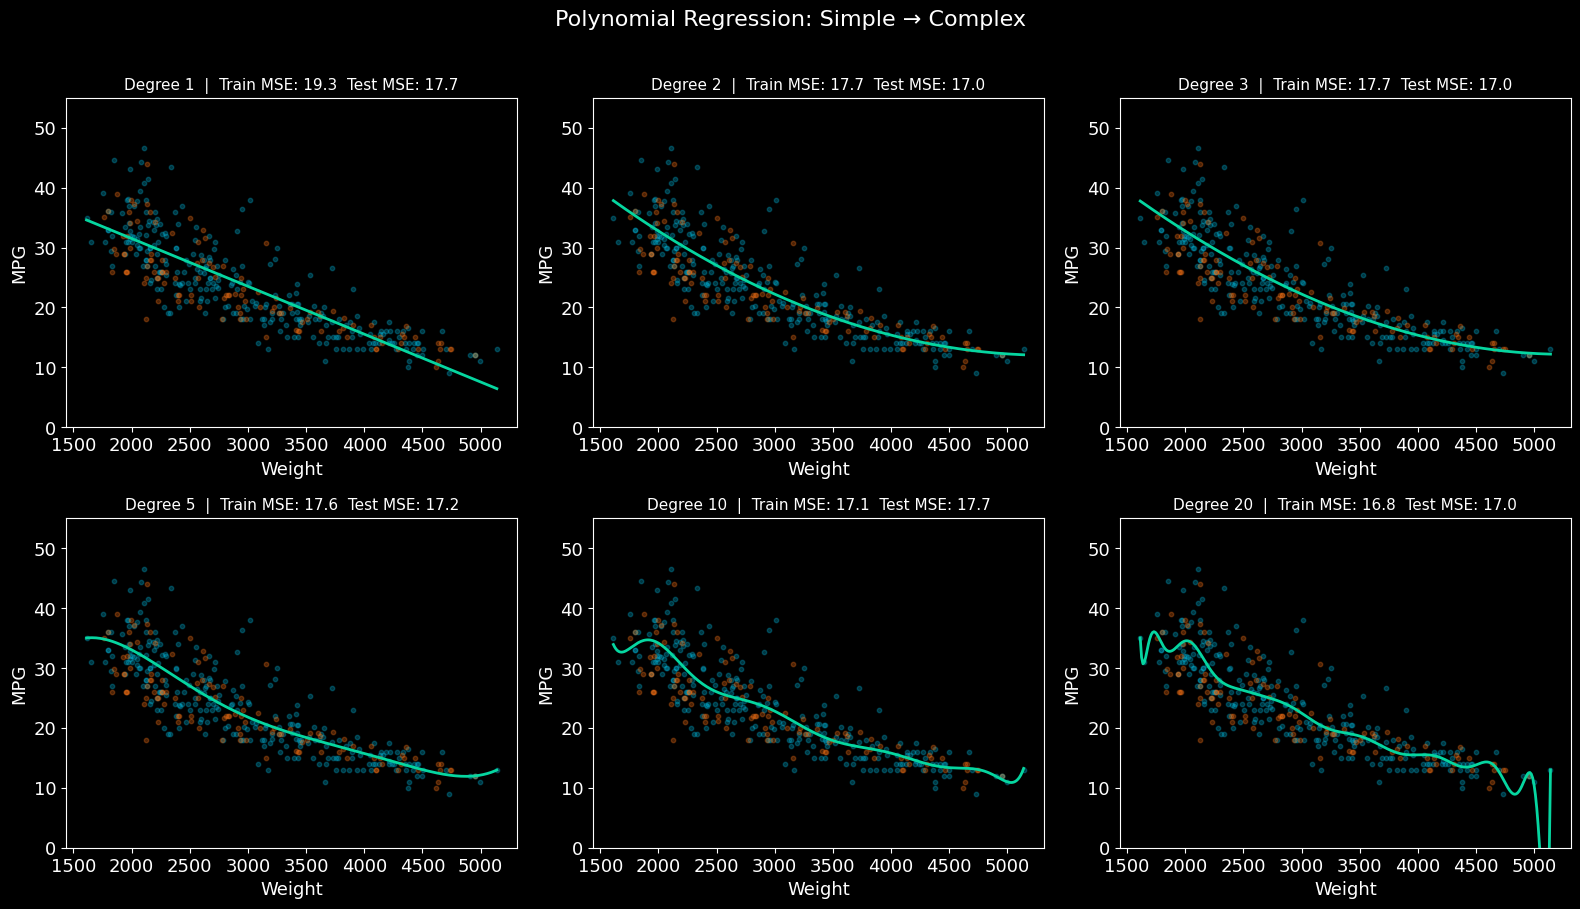

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Split: 70% train, 30% test
x_1d = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(x_1d, y, test_size=0.3, random_state=42)

# Scale features BEFORE polynomial expansion to avoid numerical blow-up
# (weight^20 without scaling → ~10^74, which breaks the solver)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

degrees = [1, 2, 3, 5, 10, 20]
train_errors, test_errors = [], []

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
x_plot = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
x_plot_sc = scaler.transform(x_plot)

for ax, deg in zip(axes.flat, degrees):
    poly = PolynomialFeatures(deg)
    X_tr_poly = poly.fit_transform(X_train_sc)
    X_te_poly = poly.transform(X_test_sc)
    X_plot_poly = poly.transform(x_plot_sc)
    
    model = LinearRegression().fit(X_tr_poly, y_train)
    
    tr_err = mean_squared_error(y_train, model.predict(X_tr_poly))
    te_err = mean_squared_error(y_test, model.predict(X_te_poly))
    train_errors.append(tr_err)
    test_errors.append(te_err)
    
    ax.scatter(X_train, y_train, alpha=0.3, s=10, color='#00B4D8')
    ax.scatter(X_test, y_test, alpha=0.3, s=10, color='#F97316')
    y_plot = model.predict(X_plot_poly)
    y_plot = np.clip(y_plot, -10, 80)
    ax.plot(x_plot, y_plot, color='#06D6A0', linewidth=2)
    ax.set_ylim(0, 55)
    ax.set_title(f'Degree {deg}  |  Train MSE: {tr_err:.1f}  Test MSE: {te_err:.1f}', fontsize=11)
    ax.set_xlabel('Weight')
    ax.set_ylabel('MPG')

plt.suptitle('Polynomial Regression: Simple → Complex', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

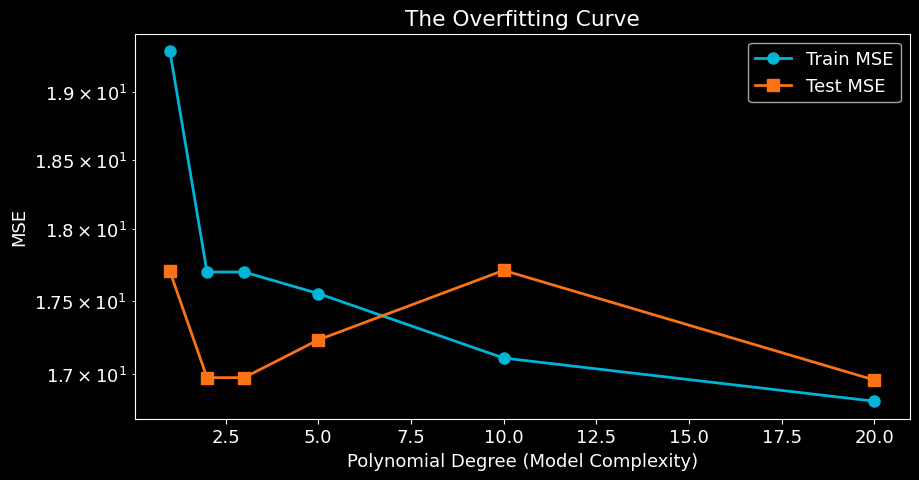

KEY INSIGHT:
Training error ALWAYS decreases with more complexity.
Test error decreases... then INCREASES. That gap is overfitting.

This is why Evaluation & Trust matters — you can't judge a model
only on the data it was trained on.


In [9]:
# The overfitting curve: train vs test error
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_errors, 'o-', color='#00B4D8', linewidth=2, markersize=8, label='Train MSE')
plt.plot(degrees, test_errors, 's-', color='#F97316', linewidth=2, markersize=8, label='Test MSE')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('MSE')
plt.title('The Overfitting Curve')
plt.legend(fontsize=13)
plt.yscale('log')
plt.show()

print("KEY INSIGHT:")
print("Training error ALWAYS decreases with more complexity.")
print("Test error decreases... then INCREASES. That gap is overfitting.")
print("\nThis is why Evaluation & Trust matters — you can't judge a model")
print("only on the data it was trained on.")

## 6. Connection to Deep Learning & LLMs

Everything we just did is the **exact same process** used to train GPT, Claude, Stable Diffusion — every AI model:

| Concept | Our Regression | GPT/Claude |
|---------|---------------|------------|
| **Model** | $y = wx + b$ (2 params) | Transformer (billions of params) |
| **Data** | 392 cars | Trillions of tokens |
| **Loss** | MSE | Cross-entropy (next token prediction) |
| **Training** | Gradient descent (100 steps) | Gradient descent (millions of steps on GPUs) |
| **Overfitting** | Polynomial degree too high | Model memorizes training text |

The fundamental loop is identical. The scale is different.

## 7. Bonus: Multiple Features (Why One Feature Isn't Enough)

Real engineering problems have many features. Let's see if using all features improves our model.

In [10]:
# Multi-feature linear regression
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
X_multi = df[features].values

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_multi, y, test_size=0.3, random_state=42)

# Single feature (weight only)
model_1 = LinearRegression().fit(X_train, y_train)
mse_1 = mean_squared_error(y_test, model_1.predict(X_test))

# All features
model_all = LinearRegression().fit(X_m_train, y_m_train)
mse_all = mean_squared_error(y_m_test, model_all.predict(X_m_test))

print(f"Weight only:    Test MSE = {mse_1:.2f}")
print(f"All 6 features: Test MSE = {mse_all:.2f}")
print(f"\nImprovement: {(1 - mse_all/mse_1)*100:.0f}% lower error")

print("\nFeature importance (coefficients):")
for f, c in sorted(zip(features, model_all.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {f:15s}: {c:+.4f}")

Weight only:    Test MSE = 17.70
All 6 features: Test MSE = 10.18

Improvement: 43% lower error

Feature importance (coefficients):
  model_year     : +0.7289
  cylinders      : -0.0926
  acceleration   : +0.0644
  horsepower     : -0.0094
  weight         : -0.0064
  displacement   : +0.0003


## Key Takeaways

1. **A model is a function with adjustable parameters.** Even the simplest (a line) can be useful.

2. **The loss function measures how wrong we are.** It's a single number that training tries to minimize.

3. **Training = gradient descent.** Compute the slope of the loss, step downhill. Repeat.

4. **Overfitting is the central challenge.** A model that memorizes training data is useless on new data. This is why we need train/test splits — and why **Evaluation & Trust** is a pillar of this course.

5. **Scale is the only difference** between what we did today and how GPT works. The loop is identical.